<a href="https://colab.research.google.com/github/eldaindahsl1203-hash/clustering_produk_skincare/blob/main/Skincare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Clustering Produk Skincare Berdasarkan Kandungan Ingredients dan Manfaat Produk Menggunakan Metode Unsupervised Learning**

In [10]:
#Mengimpor library yang dibutuhkan
# Data Handling
import os
import pandas as pd
import numpy as np

# EDA dan Analisis
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Text Pre-Processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

# Feature Extraction (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

# Merging dan Transformation
from scipy.sparse import hstack
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD

# Visualisasi
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Algoritma K-Means dan Agglomerative
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Algoritma GMM
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import ParameterGrid

#Iference
import joblib, json
from sklearn.metrics.pairwise import pairwise_distances
from scipy.sparse import hstack as sp_hstack
from sklearn.preprocessing import normalize as norm_fn

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [11]:
#Menghubungkan ke Google Drive
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Machine_Learning/Proyek"
DATA_PATH = "/content/drive/MyDrive/Machine_Learning/Proyek/skincare.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
#Mengakses file data yang akan digunakan
df = pd.read_csv(DATA_PATH)

**TAHAP EDA**

In [13]:
sns.set_style("whitegrid")

# Deskripsi Data
print("=== 5 Data Pertama ===")
display(df.head())

print("\n=== Informasi Dataset ===")
print(df.info())

print("\n=== Missing Values (%) ===")
missing = (df.isnull().sum() / len(df)) * 100
print(missing)

print("\nInsight:")
print("- Dataset mengandung beberapa missing values yang perlu ditangani sebelum proses clustering.")
print("- Kolom utama yang akan digunakan adalah 'ingridients' dan 'afterUse' karena merepresentasikan kandungan dan manfaat produk.")

=== 5 Data Pertama ===


,brand,name,type,country,ingridients,afterUse
0,The Ordinary,Glycolic Acid 7% Toning Solution,Toner,Canada,"Water,Glycolic Acid,Rosa Damascena Flower Wate...","Good For Oily Skin,Skin Texture,Reduces Large ..."
1,La Roche-Posay,Toleriane Hydrating Gentle Face Cleanser,Face Cleanser,France,"Water,Glycerin,Pentaerythrityl Tetraethylhexan...","Good For Oily Skin,Redness Reducing,Reduces Ir..."
2,The Ordinary,Niacinamide 10% + Zinc 1%,Facial Treatment,Canada,"Water,Niacinamide,Pentylene Glycol,Zinc PCA,Di...","Good For Oily Skin,Redness Reducing,Acne Fight..."
3,Youth To The People,Superfood Antioxidant Cleanser,Face Cleanser,United States,"Water,Cocamidopropyl Hydroxysultaine,Sodium Co...","Redness Reducing,Reduces Irritation,Skin Textu..."
4,COSRX,Low pH Good Morning Gel Cleanser,Face Cleanser,South Korea,"Water,Cocamidopropyl Betaine,Sodium Lauroyl Me...","Good For Oily Skin,Reduces Irritation,Reduces ..."



=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19050 entries, 0 to 19049
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   brand        19050 non-null  object
 1   name         19050 non-null  object
 2   type         19035 non-null  object
 3   country      17218 non-null  object
 4   ingridients  18731 non-null  object
 5   afterUse     17526 non-null  object
dtypes: object(6)
memory usage: 893.1+ KB
None

=== Missing Values (%) ===
brand          0.000000
name           0.000000
type           0.078740
country        9.616798
ingridients    1.674541
afterUse       8.000000
dtype: float64

Insight:
- Dataset mengandung beberapa missing values yang perlu ditangani sebelum proses clustering.
- Kolom utama yang akan digunakan adalah 'ingridients' dan 'afterUse' karena merepresentasikan kandungan dan manfaat produk.



=== Distribusi Tipe Produk ===


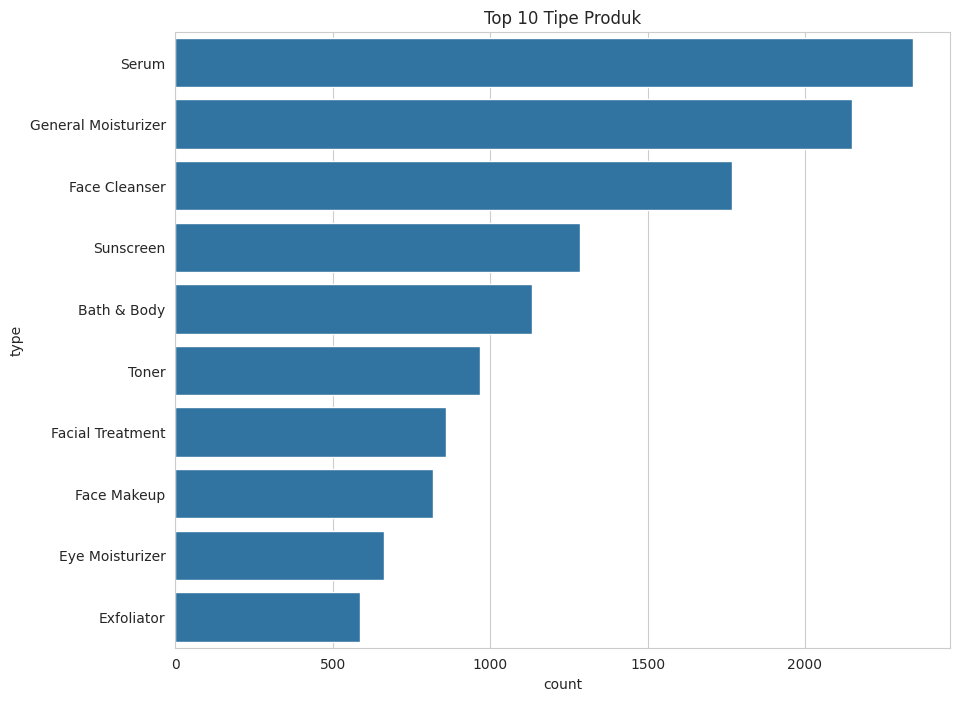

Insight:
- Distribusi tipe produk tidak seimbang.
- Namun fitur ini tidak digunakan dalam clustering utama karena tidak merepresentasikan kandungan atau manfaat secara langsung.

=== Distribusi Brand ===


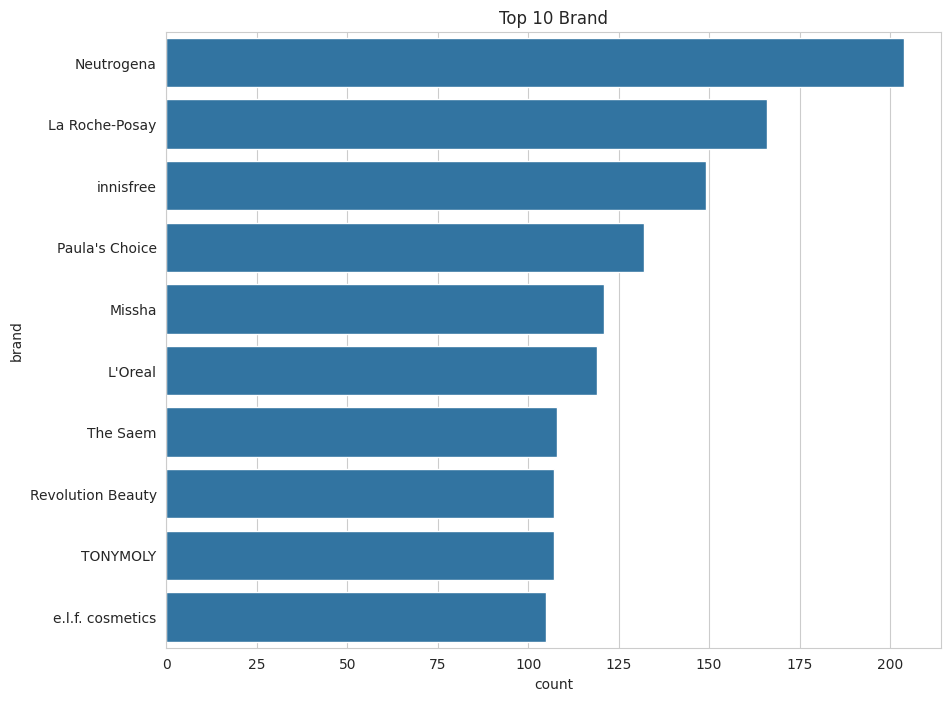

Insight:
- Beberapa brand mendominasi dataset.
- Fitur ini tidak digunakan dalam clustering karena dapat menyebabkan bias terhadap brand, bukan karakteristik produk.


In [14]:
# Analisis Fitur Non-Teks
# Tipe produk
print("\n=== Distribusi Tipe Produk ===")
plt.figure(figsize=(10,8))
sns.countplot(y='type', data=df, order=df['type'].value_counts().index[:10])
plt.title("Top 10 Tipe Produk")
plt.show()

print("Insight:")
print("- Distribusi tipe produk tidak seimbang.")
print("- Namun fitur ini tidak digunakan dalam clustering utama karena tidak merepresentasikan kandungan atau manfaat secara langsung.")

# Brand
print("\n=== Distribusi Brand ===")
plt.figure(figsize=(10,8))
sns.countplot(y='brand', data=df, order=df['brand'].value_counts().index[:10])
plt.title("Top 10 Brand")
plt.show()

print("Insight:")
print("- Beberapa brand mendominasi dataset.")
print("- Fitur ini tidak digunakan dalam clustering karena dapat menyebabkan bias terhadap brand, bukan karakteristik produk.")

In [15]:
# Analisis Teks
# Jumlah variasi teks
print("=== Variasi Teks ===")
print(f"Jumlah unique ingredients: {df['ingridients'].nunique()}")
print(f"Jumlah unique afterUse: {df['afterUse'].nunique()}")

print("\nInsight:")
print("- Variasi teks cukup tinggi, menunjukkan keberagaman data.")
print("- Hal ini mendukung penggunaan TF-IDF untuk representasi fitur.")

=== Variasi Teks ===
Jumlah unique ingredients: 18171
Jumlah unique afterUse: 2970

Insight:
- Variasi teks cukup tinggi, menunjukkan keberagaman data.
- Hal ini mendukung penggunaan TF-IDF untuk representasi fitur.


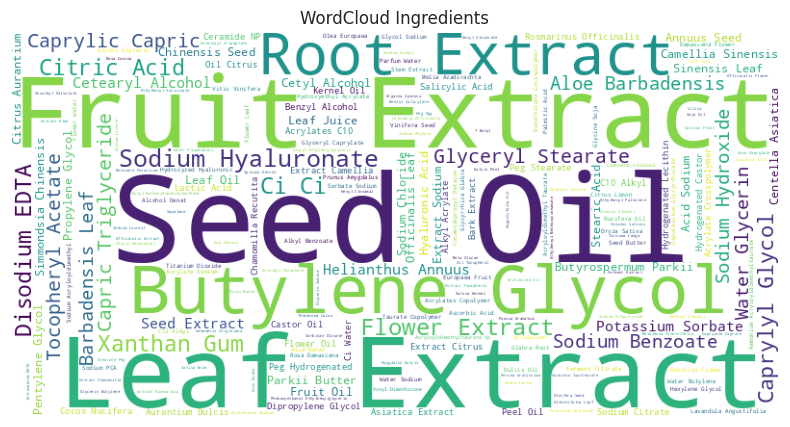

Insight:
- Kata-kata umum seperti 'extract', 'oil', dan 'acid' sering muncul.
- Hal ini menunjukkan pentingnya preprocessing seperti stopword removal dan normalisasi teks.


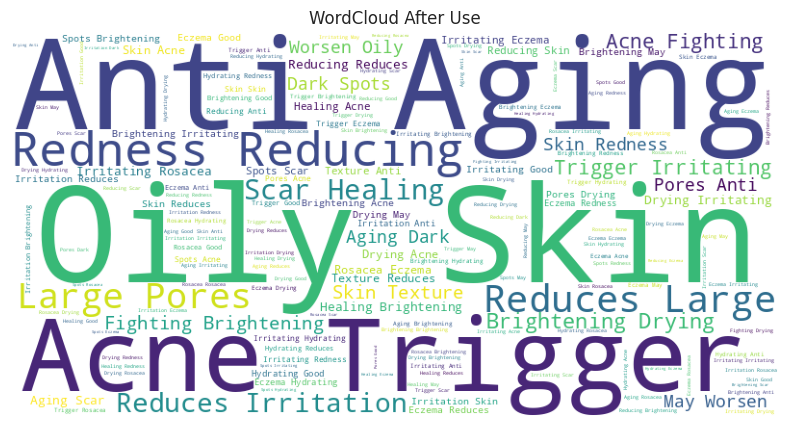

Insight:
- Kata seperti 'acne', 'oily', dan 'brightening' sering muncul.
- Fitur ini relevan untuk clustering berdasarkan manfaat produk.


In [16]:
# Justifikasi Fitur (Wordcloud)
text_ingredients = " ".join(df['ingridients'].dropna().astype(str))
wordcloud_ing = WordCloud(width=800, height=400, background_color='white').generate(text_ingredients)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_ing)
plt.axis('off')
plt.title("WordCloud Ingredients")
plt.show()

print("Insight:")
print("- Kata-kata umum seperti 'extract', 'oil', dan 'acid' sering muncul.")
print("- Hal ini menunjukkan pentingnya preprocessing seperti stopword removal dan normalisasi teks.")

text_after = " ".join(df['afterUse'].dropna().astype(str))
wordcloud_after = WordCloud(width=800, height=400, background_color='white').generate(text_after)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_after)
plt.axis('off')
plt.title("WordCloud After Use")
plt.show()

print("Insight:")
print("- Kata seperti 'acne', 'oily', dan 'brightening' sering muncul.")
print("- Fitur ini relevan untuk clustering berdasarkan manfaat produk.")

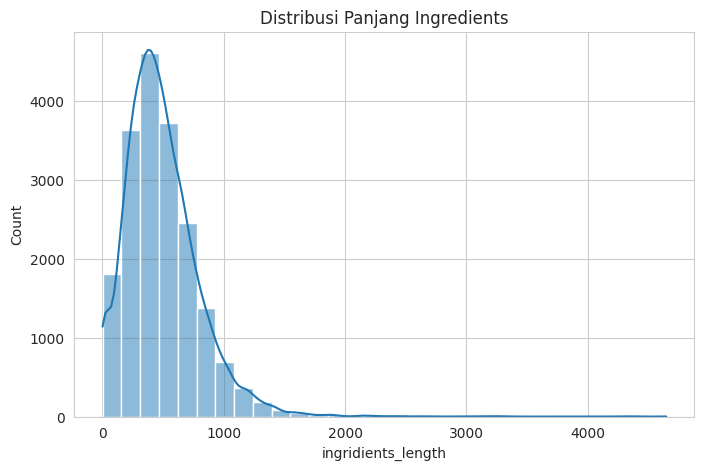

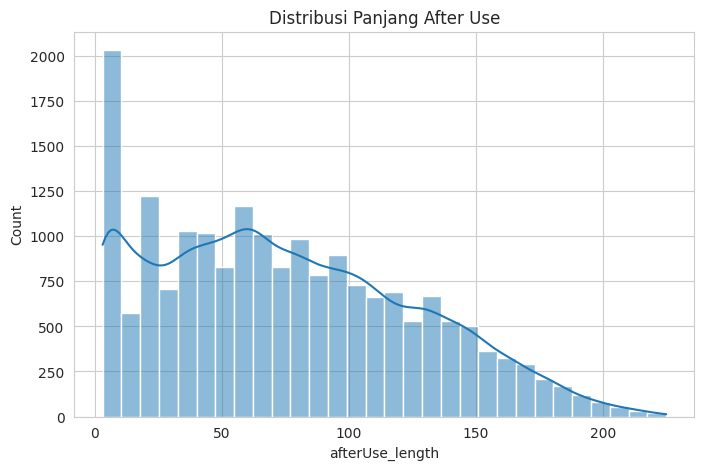

Insight:
- Terdapat variasi panjang teks yang cukup besar.
- Perlu dilakukan normalisasi teks agar tidak bias terhadap panjang dokumen.
- TF-IDF akan digunakan untuk mengatasi perbedaan panjang ini.


In [17]:
# Analisis Panjang Teks
df['ingridients_length'] = df['ingridients'].astype(str).apply(len)
df['afterUse_length'] = df['afterUse'].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['ingridients_length'], bins=30, kde=True)
plt.title("Distribusi Panjang Ingredients")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['afterUse_length'], bins=30, kde=True)
plt.title("Distribusi Panjang After Use")
plt.show()

print("Insight:")
print("- Terdapat variasi panjang teks yang cukup besar.")
print("- Perlu dilakukan normalisasi teks agar tidak bias terhadap panjang dokumen.")
print("- TF-IDF akan digunakan untuk mengatasi perbedaan panjang ini.")

In [18]:
# Analisis Frekuensi Kata
all_words = " ".join(
    (df['ingridients'].fillna("") + " " + df['afterUse'].fillna(""))
).split()
word_freq = Counter(all_words)

print("Top 20 kata paling sering muncul:")
print(word_freq.most_common(20))

print("\nInsight:")
print("- Beberapa kata memiliki frekuensi tinggi dan bersifat umum.")
print("- Kata-kata ini berpotensi menjadi noise sehingga perlu dihapus (stopwords/custom stopwords).")

Top 20 kata paling sering muncul:
[('Seed', 15850), ('Leaf', 14028), ('Fruit', 12926), ('Oily', 10363), ('Flower', 8194), ('Root', 7300), ('Large', 6452), ('For', 6078), ('Good', 5139), ('Worsen', 4285), ('Skin,Redness', 4131), ('Officinalis', 3982), ('Reducing,Reduces', 3491), ('Barbadensis', 3442), ('Reduces', 3298), ('Sativa', 2987), ('Skin,Acne', 2982), ('Alkyl', 2967), ('Annuus', 2929), ('Sinensis', 2827)]

Insight:
- Beberapa kata memiliki frekuensi tinggi dan bersifat umum.
- Kata-kata ini berpotensi menjadi noise sehingga perlu dihapus (stopwords/custom stopwords).


In [19]:
# Kesimpulan EDA
print("=== KESIMPULAN EDA ===")
print("""
1. Fitur utama yang digunakan:
   - ingridients
   - afterUse

2. Karakteristik data:
   - Data berbentuk teks dengan variasi tinggi
   - Panjang teks tidak seragam
   - Banyak kata umum yang berpotensi menjadi noise

3. Strategi preprocessing:
   - Text cleaning (lowercase, hapus tanda baca, dll)
   - Stopword removal
   - Tokenization
   - TF-IDF Vectorization

4. Fitur seperti brand, type, dan country tidak digunakan
   karena tidak merepresentasikan kandungan atau manfaat produk.
""")

=== KESIMPULAN EDA ===

1. Fitur utama yang digunakan:
   - ingridients
   - afterUse

2. Karakteristik data:
   - Data berbentuk teks dengan variasi tinggi
   - Panjang teks tidak seragam
   - Banyak kata umum yang berpotensi menjadi noise

3. Strategi preprocessing:
   - Text cleaning (lowercase, hapus tanda baca, dll)
   - Stopword removal
   - Tokenization
   - TF-IDF Vectorization

4. Fitur seperti brand, type, dan country tidak digunakan
   karena tidak merepresentasikan kandungan atau manfaat produk.



**PRE-PROCESSING**

In [20]:
# =========================
# HANDLE MISSING VALUES
# =========================
df['ingridients'] = df['ingridients'].fillna("")
df['afterUse'] = df['afterUse'].fillna("")

# =========================
# SETUP NLP
# =========================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

custom_remove_words = {
    'product', 'use', 'apply', 'good', 'skin', 'may'
}

custom_keep_words = {
    'acid', 'oil', 'extract', 'niacinamide',
    'salicylic', 'hyaluronic', 'glycerin'
}

# =========================
# POS TAGGING
# =========================
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

# =========================
# NORMALISASI PHRASE (PENTING)
# =========================
def normalize_phrases(text):
    replacements = {
        'large pores': 'large_pores',
        'dark spots': 'dark_spots',
        'fine lines': 'fine_lines',
        'anti aging': 'anti_aging',
        'acne prone': 'acne_prone',
        'skin barrier': 'skin_barrier',
        'black heads': 'blackheads'
    }
    for k, v in replacements.items():
        text = text.replace(k, v)
    return text

# =========================
# CLEANING FUNCTION
# =========================
def clean_text(text):
    text = str(text).lower()

    # phrase dulu sebelum dibersihkan
    text = normalize_phrases(text)

    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    tokens = [
        word for word in tokens
        if ((word not in stop_words and word not in custom_remove_words)
            or word in custom_keep_words)
        and len(word) >= 3
    ]

    return " ".join(tokens)

# =========================
# APPLY CLEANING
# =========================
df['ingredients_clean'] = df['ingridients'].apply(clean_text)

df = df[
    (df['ingredients_clean'].str.strip() != "") |
    (df['afterUse'].fillna("").str.strip() != "")
]

# =========================
# PROSES LABEL AFTERUSE (MultiLabelBinarizer)
# =========================
df['afterUse'] = df['afterUse'].fillna('')

afteruse_series = df['afterUse'].str.split(',').apply(
    lambda x: [i.strip() for i in x if i.strip()]
)

mlb = MultiLabelBinarizer()
afteruse_matrix = mlb.fit_transform(afteruse_series)

afteruse_df = pd.DataFrame(
    afteruse_matrix, columns=mlb.classes_, index=df.index
)

if '' in afteruse_df.columns:
    afteruse_df = afteruse_df.drop(columns=[''])

print("\nDaftar label yang ditemukan:", mlb.classes_)

# =========================
# TF-IDF INGREDIENTS
# =========================
tfidf_ing = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)

X_ing = tfidf_ing.fit_transform(df['ingredients_clean'])

# Cek Shape
print("Shape Ingredients (TF-IDF):", X_ing.shape)
print("Shape AfterUse (Binary):", afteruse_df.shape)

# =========================
# GABUNG FEATURE
# =========================
X_combined = hstack([
    X_ing,
    afteruse_df.values * 2.0
])

# =========================
# DIMENSION REDUCTION (SVD)
# =========================
n_components_range = [50, 75, 100, 150, 200]
best_n = None
best_var = 0

print("\n=== HYPERTUNING SVD N_COMPONENTS ===")
for n in n_components_range:
    svd_test = TruncatedSVD(n_components=n, random_state=42)
    X_test = svd_test.fit_transform(X_combined)
    var = svd_test.explained_variance_ratio_.sum()

    print(f"n={n} | Explained Variance={var:.4f}")

    if var >= 0.60 and best_n is None:
        best_n = n  # Ambil yang pertama memenuhi threshold

if best_n is None:
    best_n = n_components_range[-1]

print(f"\nPilihan n_components optimal: {best_n}")

svd = TruncatedSVD(n_components=best_n, random_state=42)
X_reduced = svd.fit_transform(X_combined)

explained_var = svd.explained_variance_ratio_.sum()
print("\nExplained variance:", explained_var)

# =========================
# NORMALISASI FINAL
# =========================
X_final = normalize(X_reduced)

# =========================
# SAMPLE OUTPUT
# =========================
print("\nSample Clean Data")
print(df[['ingredients_clean']].sample(5))
print(df[['afterUse']].sample(5))

print("\nJumlah data setelah cleaning:", len(df))


Daftar label yang ditemukan: ['Acne Fighting' 'Acne Trigger' 'Anti-Aging' 'Brightening' 'Dark Spots'
 'Drying' 'Eczema' 'Good For Oily Skin' 'Hydrating' 'Irritating'
 'May Worsen Oily Skin' 'Redness Reducing' 'Reduces Irritation'
 'Reduces Large Pores' 'Rosacea' 'Scar Healing' 'Skin Texture']
Shape Ingredients (TF-IDF): (18726, 4000)
Shape AfterUse (Binary): (18726, 17)

=== HYPERTUNING SVD N_COMPONENTS ===
n=50 | Explained Variance=0.9519
n=75 | Explained Variance=0.9558
n=100 | Explained Variance=0.9588
n=150 | Explained Variance=0.9634
n=200 | Explained Variance=0.9670

Pilihan n_components optimal: 50

Explained variance: 0.9518634651149098

Sample Clean Data
                                       ingredients_clean
788    water stearic acid copernicia cerifera wax pol...
16706  water cyclopentasiloxane ethylhexyl isononanoa...
18716  undaria pinnatifida extract glycerin methylpro...
3470   water stearic acid glycerin potassium hydroxid...
13210  telopea speciosissima flower leaf e

In [21]:
# FIT PCA SATU KALI UNTUK SEMUA
pca_shared = PCA(n_components=2, random_state=42)
X_2d_shared = pca_shared.fit_transform(X_final)

**MODELLING / CLUSTERING (K-Means)**

=== HYPERTUNING & EVALUASI KMEANS ===
k=2 | Silhouette=0.1389 | DBI=2.7702 | Inertia=10912.41
k=3 | Silhouette=0.1112 | DBI=2.4718 | Inertia=9949.71
k=4 | Silhouette=0.1115 | DBI=2.1855 | Inertia=9348.07
k=5 | Silhouette=0.1279 | DBI=2.2719 | Inertia=8761.59
k=6 | Silhouette=0.1424 | DBI=2.1563 | Inertia=8279.53
k=7 | Silhouette=0.1509 | DBI=2.0927 | Inertia=7925.93
k=8 | Silhouette=0.1653 | DBI=1.9483 | Inertia=7510.27
k=9 | Silhouette=0.1623 | DBI=1.9157 | Inertia=7191.73
k=10 | Silhouette=0.1695 | DBI=1.8487 | Inertia=6956.24


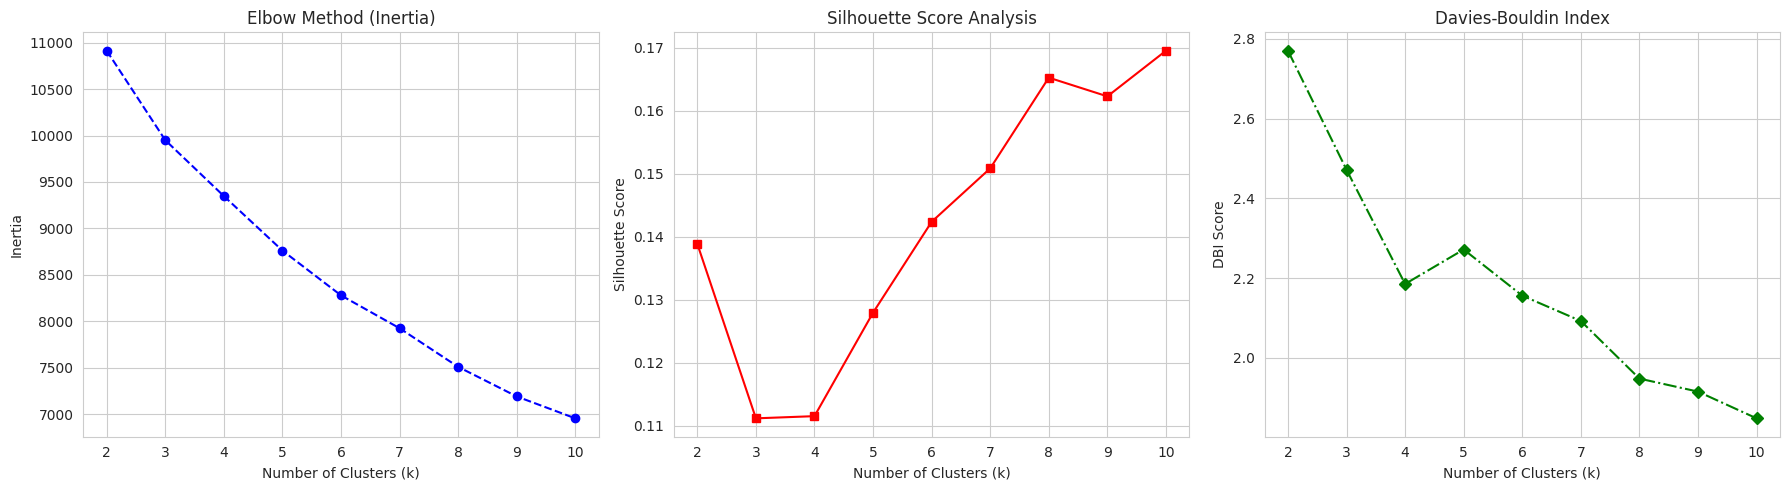

In [22]:
# =========================
# EVALUASI NILAI K & HYPERTUNING
# =========================
param_grid = {
    'n_clusters': range(2, 11), # Ini adalah K_range untuk Elbow & Silhouette
    'n_init': [10, 20],
    'init': ['k-means++', 'random']
}

inertia_list = []
sil_list = []
dbi_list = []
results_tuning = []

print("=== HYPERTUNING & EVALUASI KMEANS ===")
for params in ParameterGrid(param_grid):
    km = KMeans(random_state=42, **params)
    lbl = km.fit_predict(X_final)

    # Hitung metrik evaluasi
    sil = silhouette_score(X_final, lbl)
    dbi = davies_bouldin_score(X_final, lbl)

    # Simpan hasil untuk analisis
    results_tuning.append({**params, 'sil': sil, 'dbi': dbi, 'inertia': km.inertia_})

    # Ambil data untuk grafik Elbow & ringkasan (fokus pada n_init 20 agar stabil)
    if params['n_init'] == 20 and params['init'] == 'k-means++':
        inertia_list.append(km.inertia_)
        sil_list.append(sil)
        dbi_list.append(dbi)
        print(f"k={params['n_clusters']} | Silhouette={sil:.4f} | DBI={dbi:.4f} | Inertia={km.inertia_:.2f}")

# =========================
# VISUALISASI SEBELUM MEMILIH K
# =========================
plt.figure(figsize=(18, 5))

# 1. Plot Elbow Method (Inertia)
plt.subplot(1, 3, 1)
plt.plot(range(2, 11), inertia_list, marker='o', color='b', linestyle='--')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

# 2. Plot Silhouette Score
plt.subplot(1, 3, 2)
plt.plot(range(2, 11), sil_list, marker='s', color='r', linestyle='-')
plt.title('Silhouette Score Analysis')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

# 3. Plot Davies-Bouldin Index (Cari Titik Terendah)
plt.subplot(1, 3, 3)
plt.plot(range(2, 11), dbi_list, marker='D', color='g', linestyle='-.')
plt.title('Davies-Bouldin Index')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('DBI Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# =========================
# PENENTUAN BEST K &  ANALISIS AKHIR
# =========================
print("=== RINGKASAN ANALISIS NILAI K ===")
for k_val, s_val, d_val in zip(range(2, 11), sil_list, dbi_list):
    print(f"k={k_val} | Sil={s_val:.4f} | DBI={d_val:.4f}")

best_k_kmeans = 10
print(f"\nMemilih Best k: {best_k_kmeans}")

=== RINGKASAN ANALISIS NILAI K ===
k=2 | Sil=0.1389 | DBI=2.7702
k=3 | Sil=0.1112 | DBI=2.4718
k=4 | Sil=0.1115 | DBI=2.1855
k=5 | Sil=0.1279 | DBI=2.2719
k=6 | Sil=0.1424 | DBI=2.1563
k=7 | Sil=0.1509 | DBI=2.0927
k=8 | Sil=0.1653 | DBI=1.9483
k=9 | Sil=0.1623 | DBI=1.9157
k=10 | Sil=0.1695 | DBI=1.8487

Memilih Best k: 10


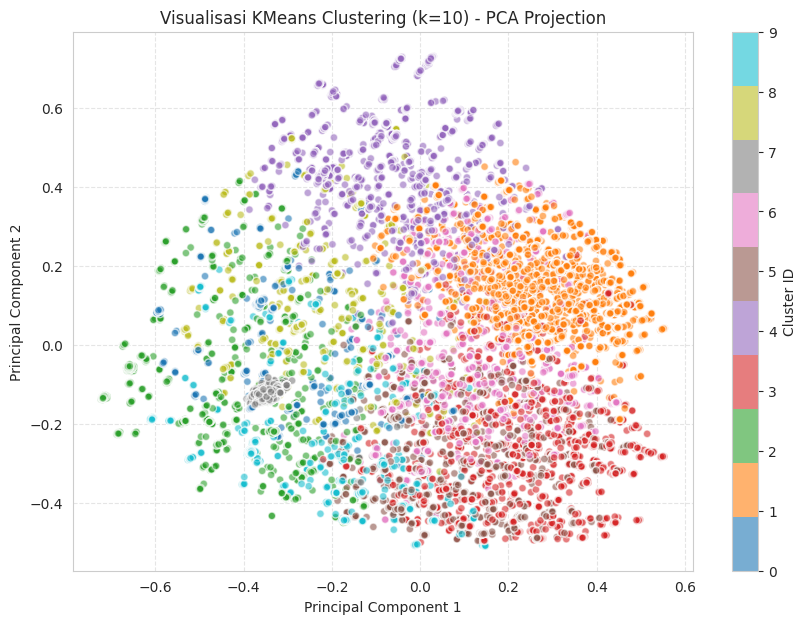


=== HASIL FINAL K-MEANS ===
Silhouette Score : 0.1695
Davies-Bouldin Index : 1.8487

=== TOP TERMS PER CLUSTER ===

Cluster 0:
Eczema, Brightening, Acne Trigger, Reduces Irritation, May Worsen Oily Skin, Drying, Hydrating, dimethicone, Anti-Aging, Irritating

Cluster 1:
Irritating, Drying, Brightening, Reduces Large Pores, Good For Oily Skin, Acne Fighting, Anti-Aging, Eczema, Skin Texture, Dark Spots

Cluster 2:
Acne Trigger, May Worsen Oily Skin, Brightening, Drying, Hydrating, Eczema, Reduces Irritation, Redness Reducing, Anti-Aging, oil

Cluster 3:
Anti-Aging, Redness Reducing, Brightening, Skin Texture, Dark Spots, Irritating, Scar Healing, Acne Trigger, Reduces Irritation, Good For Oily Skin

Cluster 4:
Drying, Irritating, Reduces Large Pores, Acne Trigger, Eczema, Reduces Irritation, Rosacea, Brightening, Anti-Aging, May Worsen Oily Skin

Cluster 5:
Redness Reducing, Good For Oily Skin, Brightening, Acne Fighting, Reduces Irritation, Acne Trigger, Anti-Aging, Scar Healing, May 

In [24]:
# =========================
# MODEL FINAL K-MEANS
# =========================
# Kita gunakan parameter terbaik hasil tuning sebelumnya
kmeans_final = KMeans(n_clusters=best_k_kmeans, n_init=20, init='k-means++', random_state=42)
labels_kmeans = kmeans_final.fit_predict(X_final)

# Simpan ke dataframe utama
df['cluster_kmeans'] = labels_kmeans

# =========================
# VISUALISASI (PCA 2D)
# =========================
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_2d_shared[:, 0],
    X_2d_shared[:, 1],
    c=labels_kmeans,
    cmap='tab10',
    alpha=0.6,
    edgecolors='w',
    s=30
)

plt.title(f"Visualisasi KMeans Clustering (k={best_k_kmeans}) - PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# =========================
# METRIK FINAL
# =========================
sil_kmeans = silhouette_score(X_final, labels_kmeans)
dbi_kmeans = davies_bouldin_score(X_final, labels_kmeans)

print("\n=== HASIL FINAL K-MEANS ===")
print(f"Silhouette Score : {sil_kmeans:.4f}")
print(f"Davies-Bouldin Index : {dbi_kmeans:.4f}")

# =========================
# TOP TERMS (KMEANS) - DISESUAIKAN
# =========================

# 1. Ambil nama fitur dari sumber yang tersisa
terms_ing = list(tfidf_ing.get_feature_names_out())
terms_afteruse = list(afteruse_df.columns) # Label biner (17 label)

# 2. Gabungkan SEMUA fitur sesuai urutan hstack saat preprocessing
# Urutan: X_ing dulu, baru afteruse_df
all_terms = terms_ing + terms_afteruse

# 3. Ambil pusat cluster (centroid) dari ruang X_final
centroids = kmeans_final.cluster_centers_

# 4. Proyeksikan kembali ke ruang fitur asli (sebelum SVD)
# SVD components menghubungkan ruang tereduksi (100) kembali ke ruang asli (4000+17)
original_space_centroids = centroids @ svd.components_

print("\n=== TOP TERMS PER CLUSTER ===")
for i in range(best_k_kmeans):
    print(f"\nCluster {i}:")

    # Ambil 10 indeks fitur dengan nilai bobot tertinggi di cluster tersebut
    top_idx = original_space_centroids[i].argsort()[-10:][::-1]

    # Ambil nama fiturnya
    top_terms = []
    for j in top_idx:
        if j < len(all_terms):
            top_terms.append(all_terms[j])

    print(", ".join(top_terms))

# =========================
# CONTOH DATA PER CLUSTER
# =========================
print("\n=== SAMPLE DATA PER CLUSTER ===")
for i in range(best_k_kmeans):
    cluster_size = len(df[df['cluster_kmeans'] == i])
    print(f"\nCluster {i} (Total: {cluster_size} products):")

    sample = df[df['cluster_kmeans'] == i][
        ['ingridients', 'afterUse']
    ].head(3)

    print(sample)

**MODELLING / CLUSTERING (Agglomerative Clustering)**

=== EVALUASI NILAI K AGGLO ===
k=2 | Silhouette=0.1198 | DBI=2.9775
k=3 | Silhouette=0.0963 | DBI=2.4689
k=4 | Silhouette=0.0940 | DBI=2.5065
k=5 | Silhouette=0.1026 | DBI=2.2378
k=6 | Silhouette=0.1072 | DBI=2.1600
k=7 | Silhouette=0.1206 | DBI=2.2567
k=8 | Silhouette=0.1296 | DBI=2.1727
k=9 | Silhouette=0.1395 | DBI=2.1113
k=10 | Silhouette=0.1201 | DBI=2.1106


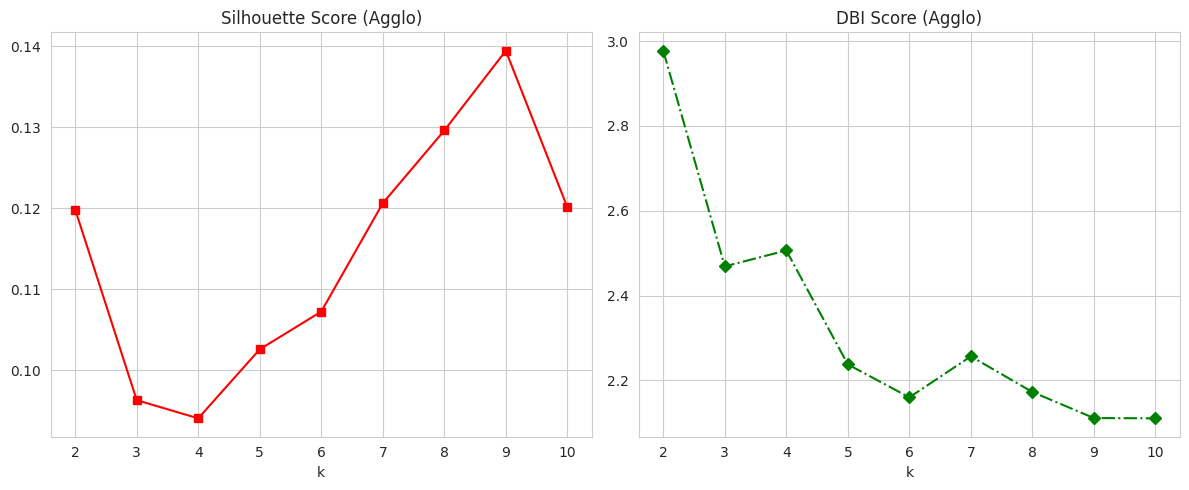

In [25]:
# =========================
# EVALUASI NILAI K (AGGLO)
# =========================
sil_scores_agg = []
dbi_scores_agg = []
K_range = range(2, 11)

print("=== EVALUASI NILAI K AGGLO ===")
for k in K_range:
    # Menggunakan ward linkage (standar industri)
    agglo = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agglo.fit_predict(X_final)

    sil = silhouette_score(X_final, labels)
    dbi = davies_bouldin_score(X_final, labels)

    sil_scores_agg.append(sil)
    dbi_scores_agg.append(dbi)

    print(f"k={k} | Silhouette={sil:.4f} | DBI={dbi:.4f}")

# =========================
# VISUALISASI EVALUASI
# =========================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, sil_scores_agg, marker='s', color='r', linestyle='-')
plt.title("Silhouette Score (Agglo)")
plt.xlabel("k")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_range, dbi_scores_agg, marker='D', color='g', linestyle='-.')
plt.title("DBI Score (Agglo)")
plt.xlabel("k")
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# Mengambil Nilai Best K
best_k_agg = 9
print(f"Memilih Best k Agglo: {best_k_agg}")

Memilih Best k Agglo: 9


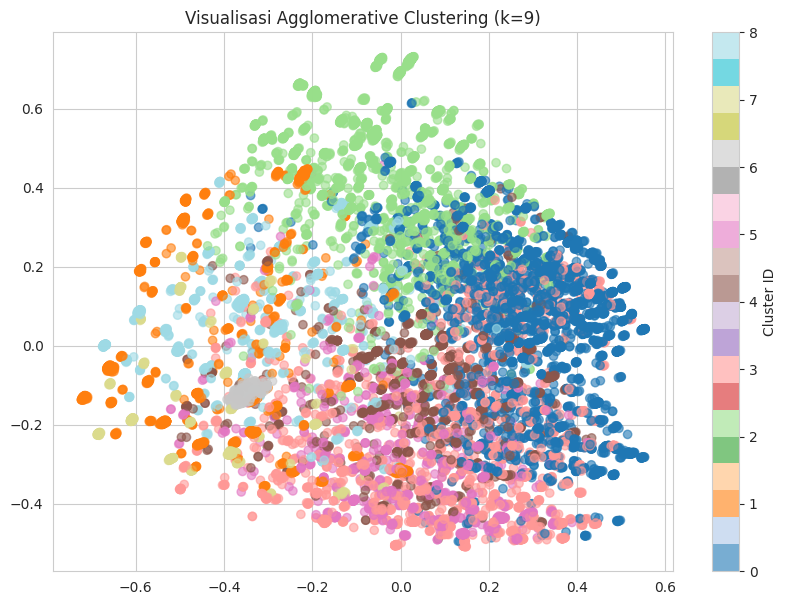


=== HASIL FINAL AGGLOMERATIVE ===
Silhouette Score : 0.1395
Davies-Bouldin Index : 2.1113

=== TOP TERMS PER CLUSTER (AGGLO) ===

Cluster 0:
Irritating, Brightening, Good For Oily Skin, Anti-Aging, Acne Fighting, Drying, Reduces Large Pores, Skin Texture, Scar Healing, Redness Reducing

Cluster 1:
Acne Trigger, Brightening, May Worsen Oily Skin, Drying, Hydrating, Eczema, Reduces Irritation, oil, Rosacea, extract

Cluster 2:
Drying, Irritating, Reduces Large Pores, Acne Trigger, Brightening, Anti-Aging, Eczema, Reduces Irritation, Rosacea, Scar Healing

Cluster 3:
Redness Reducing, Anti-Aging, Brightening, Dark Spots, Skin Texture, Acne Trigger, Reduces Irritation, Irritating, May Worsen Oily Skin, Eczema

Cluster 4:
Scar Healing, Anti-Aging, Brightening, Irritating, Acne Trigger, Eczema, May Worsen Oily Skin, Reduces Irritation, Rosacea, Redness Reducing

Cluster 5:
Good For Oily Skin, Brightening, Redness Reducing, Acne Fighting, Reduces Irritation, Acne Trigger, May Worsen Oily Ski

In [27]:
# MODEL FINAL AGGLO
agglo_final = AgglomerativeClustering(n_clusters=best_k_agg, linkage='ward')
labels_agg = agglo_final.fit_predict(X_final)
df['cluster_agg'] = labels_agg

# =========================
# VISUALISASI PCA 2D
# =========================
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_2d_shared[:, 0],
    X_2d_shared[:, 1],
    c=labels_agg,
    cmap='tab20',
    alpha=0.6
)

plt.title(f"Visualisasi Agglomerative Clustering (k={best_k_agg})")
plt.colorbar(scatter, label="Cluster ID")
plt.show()

# =========================
# METRIK FINAL
# =========================
sil_agg = silhouette_score(X_final, labels_agg)
dbi_agg = davies_bouldin_score(X_final, labels_agg)

print("\n=== HASIL FINAL AGGLOMERATIVE ===")
print(f"Silhouette Score : {sil_agg:.4f}")
print(f"Davies-Bouldin Index : {dbi_agg:.4f}")

# =========================
# TOP TERMS (AGGLO) - FIX
# =========================
from sklearn.neighbors import NearestCentroid

# 1. Gabungkan nama fitur sesuai urutan X_final
terms_ing = list(tfidf_ing.get_feature_names_out())
terms_afteruse = list(afteruse_df.columns)
all_terms = terms_ing + terms_afteruse

# 2. Karena Agglo tidak punya centroids, kita hitung rata-rata posisi cluster
clf = NearestCentroid()
clf.fit(X_final, labels_agg)
centroids_agg = clf.centroids_

# 3. Proyeksi balik ke ruang asli
original_space_centroids_agg = centroids_agg @ svd.components_

print("\n=== TOP TERMS PER CLUSTER (AGGLO) ===")
for i in range(best_k_agg):
    print(f"\nCluster {i}:")
    top_idx = original_space_centroids_agg[i].argsort()[-10:][::-1]

    top_terms = []
    for j in top_idx:
        if j < len(all_terms):
            top_terms.append(all_terms[j])

    print(", ".join(top_terms))

# =========================
# CONTOH DATA PER CLUSTER
# =========================
print("\n=== SAMPLE DATA PER CLUSTER ===")
for i in range(best_k_agg):
    cluster_size = len(df[df['cluster_agg'] == i])
    print(f"\nCluster {i} (Total: {cluster_size} products):")

    sample = df[df['cluster_agg'] == i][
        ['ingridients', 'afterUse']
    ].head(3)

    print(sample)

**MODELLING / CLUSTERING (Gaussian Mixture Model (GMM))**

=== PROSES HYPERTUNING GMM ===
k=2 | Sil=0.1629 | DBI=2.9116 | BIC=-3596688.80
k=3 | Sil=0.1017 | DBI=3.2156 | BIC=-3901271.07
k=4 | Sil=0.0959 | DBI=2.7450 | BIC=-4106373.49
k=5 | Sil=0.0508 | DBI=3.9547 | BIC=-4233670.35
k=6 | Sil=0.0732 | DBI=2.8595 | BIC=-4373529.44
k=7 | Sil=0.0949 | DBI=2.6025 | BIC=-4367125.90
k=8 | Sil=0.1031 | DBI=2.7919 | BIC=-4535445.14
k=9 | Sil=0.1193 | DBI=2.2666 | BIC=-4573007.62
k=10 | Sil=0.0928 | DBI=2.5344 | BIC=-4601767.02


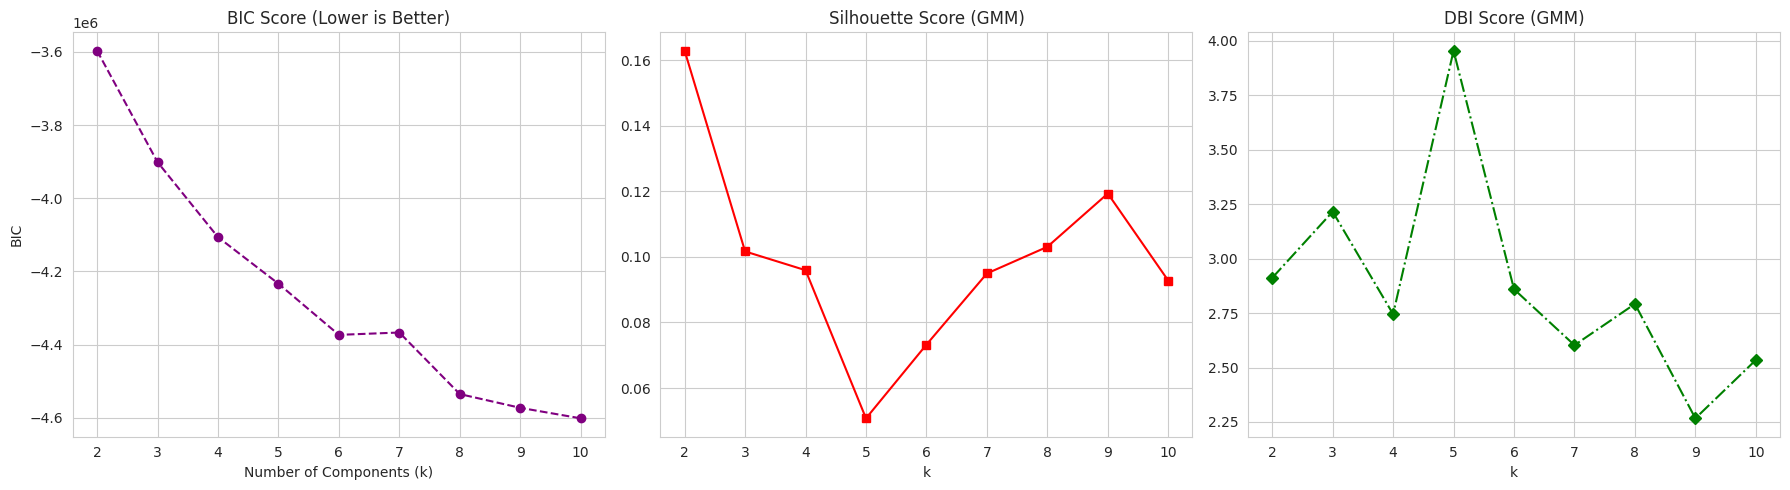

In [28]:
# =========================
# EVALUASI & HYPERTUNING GMM
# =========================
param_grid_gmm = {
    'n_components': range(2, 11),
    'covariance_type': ['full', 'tied'], # 'full' biasanya paling akurat untuk data kompleks
    'n_init': [2] # GMM lebih berat, n_init kecil saja sudah cukup
}

sil_list_gmm = []
dbi_list_gmm = []
bic_list_gmm = []
results_gmm = []

print("=== PROSES HYPERTUNING GMM ===")
for params in ParameterGrid(param_grid_gmm):
    gmm_test = GaussianMixture(random_state=42, **params)
    gmm_test.fit(X_final)
    lbl = gmm_test.predict(X_final)

    # Hitung Metrik
    sil = silhouette_score(X_final, lbl)
    dbi = davies_bouldin_score(X_final, lbl)
    bic = gmm_test.bic(X_final) # Metrik khas GMM (semakin rendah semakin baik)

    results_gmm.append({**params, 'sil': sil, 'dbi': dbi, 'bic': bic})

    # Ambil data untuk grafik (fokus pada covariance_type 'full')
    if params['covariance_type'] == 'full':
        sil_list_gmm.append(sil)
        dbi_list_gmm.append(dbi)
        bic_list_gmm.append(bic)
        print(f"k={params['n_components']} | Sil={sil:.4f} | DBI={dbi:.4f} | BIC={bic:.2f}")

# =========================
# VISUALISASI EVALUASI GMM
# =========================
plt.figure(figsize=(18, 5))

# 1. Plot BIC (Cari nilai terendah/siku)
plt.subplot(1, 3, 1)
plt.plot(range(2, 11), bic_list_gmm, marker='o', color='purple', linestyle='--')
plt.title('BIC Score (Lower is Better)')
plt.xlabel('Number of Components (k)')
plt.ylabel('BIC')
plt.grid(True)

# 2. Plot Silhouette
plt.subplot(1, 3, 2)
plt.plot(range(2, 11), sil_list_gmm, marker='s', color='r', linestyle='-')
plt.title('Silhouette Score (GMM)')
plt.xlabel('k')
plt.grid(True)

# 3. Plot DBI
plt.subplot(1, 3, 3)
plt.plot(range(2, 11), dbi_list_gmm, marker='D', color='g', linestyle='-.')
plt.title('DBI Score (GMM)')
plt.xlabel('k')
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
# =========================
# EVALUASI NILAI K GMM
# =========================
best_k_gmm = 9
print(f"Memilih Best k GMM: {best_k_gmm}")

Memilih Best k GMM: 9


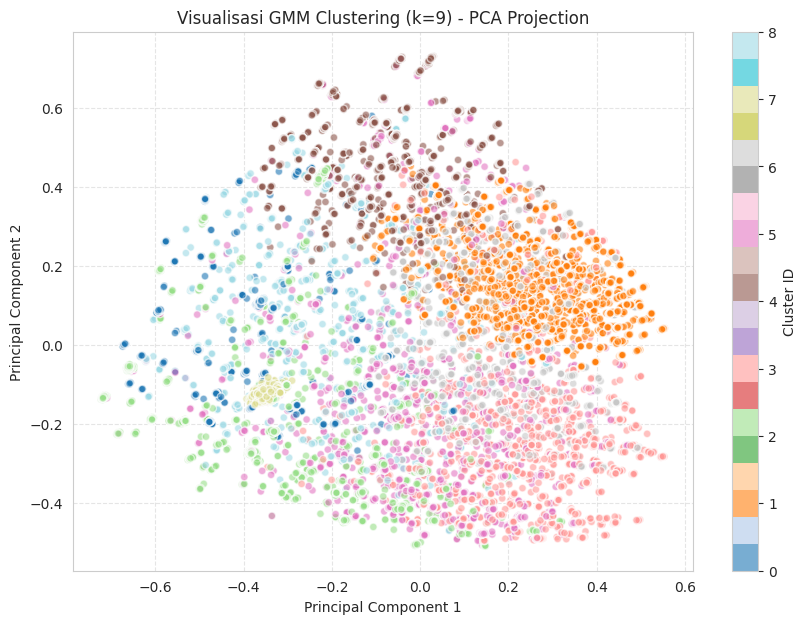

=== HASIL FINAL GMM ===
Silhouette Score : 0.1193
Davies-Bouldin Index : 2.2666

=== TOP TERMS PER CLUSTER (GMM) ===

Cluster 0:
Eczema, Acne Trigger, Brightening, May Worsen Oily Skin, Reduces Irritation, Drying, Hydrating, Irritating, Anti-Aging, dimethicone

Cluster 1:
Irritating, Reduces Large Pores, Drying, Brightening, Good For Oily Skin, Anti-Aging, Acne Fighting, Dark Spots, Skin Texture, Redness Reducing

Cluster 2:
Acne Trigger, Reduces Irritation, Brightening, May Worsen Oily Skin, Redness Reducing, Drying, Anti-Aging, Hydrating, Scar Healing, extract

Cluster 3:
Anti-Aging, Redness Reducing, Brightening, Dark Spots, Skin Texture, Irritating, Scar Healing, Acne Trigger, Good For Oily Skin, Reduces Irritation

Cluster 4:
Drying, Irritating, Reduces Large Pores, Acne Trigger, Eczema, Reduces Irritation, Rosacea, Brightening, Anti-Aging, May Worsen Oily Skin

Cluster 5:
Good For Oily Skin, Brightening, Redness Reducing, Acne Fighting, Reduces Irritation, Acne Trigger, Anti-Agin

In [30]:
# Di bagian MODEL FINAL GMM, ganti:
best_gmm_params = max(
    [r for r in results_gmm if r['n_components'] == best_k_gmm],
    key=lambda x: x['sil']
)
gmm_final = GaussianMixture(
    n_components=best_k_gmm,
    covariance_type=best_gmm_params['covariance_type'],
    n_init=2, random_state=42
)

labels_gmm = gmm_final.fit_predict(X_final)
df['cluster_gmm'] = labels_gmm

# =========================
# VISUALISASI FINAL GMM (PCA 2D)
# =========================
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_2d_shared[:, 0],
    X_2d_shared[:, 1],
    c=labels_gmm,
    cmap='tab20', # Menggunakan tab20 agar warna k=9/10 terlihat beda
    alpha=0.6,
    edgecolors='w',
    s=30
)

plt.title(f"Visualisasi GMM Clustering (k={best_k_gmm}) - PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# =========================
# METRIK FINAL & TOP TERMS
# =========================
sil_gmm = silhouette_score(X_final, labels_gmm)
dbi_gmm = davies_bouldin_score(X_final, labels_gmm)

print("=== HASIL FINAL GMM ===")
print(f"Silhouette Score : {sil_gmm:.4f}")
print(f"Davies-Bouldin Index : {dbi_gmm:.4f}")

# Proyeksi Top Terms (Sama dengan K-Means)
centroids_gmm = gmm_final.means_
original_space_centroids_gmm = centroids_gmm @ svd.components_

print("\n=== TOP TERMS PER CLUSTER (GMM) ===")
for i in range(best_k_gmm):
    print(f"\nCluster {i}:")
    top_idx = original_space_centroids_gmm[i].argsort()[-10:][::-1]
    top_terms = [all_terms[j] for j in top_idx if j < len(all_terms)]
    print(", ".join(top_terms))

# =========================
# CONTOH DATA PER CLUSTER (GMM)
# =========================
print("\n=== SAMPLE DATA PER CLUSTER (GMM) ===")
for i in range(best_k_gmm):
    cluster_size = len(df[df['cluster_gmm'] == i])
    print(f"\nCluster {i} (Total: {cluster_size} products):")

    sample = df[df['cluster_gmm'] == i][
        ['ingridients', 'afterUse']
    ].head(3)

    print(sample)

**EVALUASI**

In [31]:
# =========================
# PERBANDINGAN METRIK FINAL
# =========================
results = pd.DataFrame({
    'Algoritma': ['K-Means', 'Agglo', 'GMM'],
    'Best K': [best_k_kmeans, best_k_agg, best_k_gmm],
    'Silhouette Score': [sil_kmeans, sil_agg, sil_gmm],
    'DBI Score': [dbi_kmeans, dbi_agg, dbi_gmm]
})

print("=== PERBANDINGAN MODEL ===")
print(results.to_string(index=False))

=== PERBANDINGAN MODEL ===
Algoritma  Best K  Silhouette Score  DBI Score
  K-Means      10          0.169545   1.848702
    Agglo       9          0.139466   2.111269
      GMM       9          0.119320   2.266582


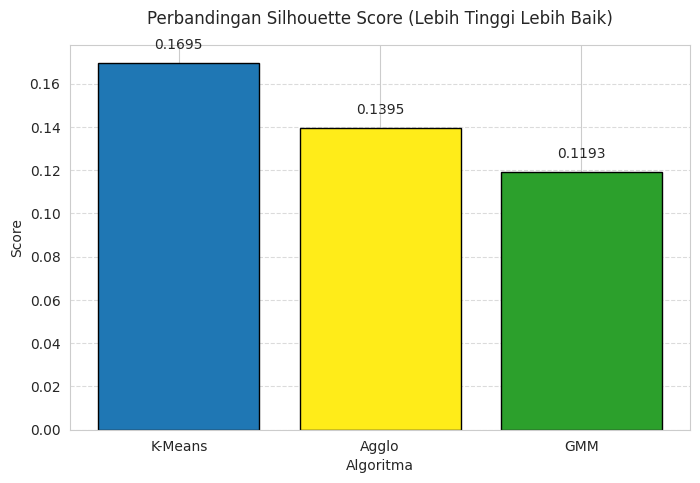

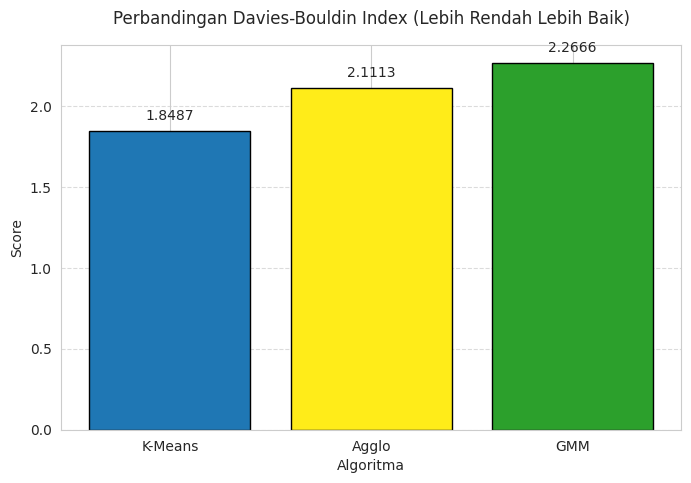


=== RINGKASAN REKOMENDASI ===
Algoritma dengan Silhouette terbaik : K-Means
Algoritma dengan DBI terbaik        : K-Means
KESIMPULAN: K-Means adalah model terbaik untuk dataset skincare ini.


In [32]:
# =========================
# VISUALISASI PERBANDINGAN (Background Putih)
# =========================
# Mengatur style agar background putih bersih
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# 1. Visualisasi Perbandingan Silhouette Score
plt.figure(figsize=(8, 5))
colors = ['#1f77b4', '#ffec19', '#2ca02c'] # Blue, Yellow (Agglo), Green

bars_sil = plt.bar(results['Algoritma'], results['Silhouette Score'], color=colors, edgecolor='black')

plt.title("Perbandingan Silhouette Score (Lebih Tinggi Lebih Baik)", pad=15)
plt.ylabel("Score")
plt.xlabel("Algoritma")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas bar
for bar in bars_sil:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom')

plt.show()

# 2. Visualisasi Perbandingan DBI Score
plt.figure(figsize=(8, 5))

bars_dbi = plt.bar(results['Algoritma'], results['DBI Score'], color=colors, edgecolor='black')

plt.title("Perbandingan Davies-Bouldin Index (Lebih Rendah Lebih Baik)", pad=15)
plt.ylabel("Score")
plt.xlabel("Algoritma")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas bar
for bar in bars_dbi:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval, 4), ha='center', va='bottom')

plt.show()

# =========================
# KESIMPULAN AKHIR
# =========================
best_sil_algo = results.loc[results['Silhouette Score'].idxmax(), 'Algoritma']
best_dbi_algo = results.loc[results['DBI Score'].idxmin(), 'Algoritma']

print("\n=== RINGKASAN REKOMENDASI ===")
print(f"Algoritma dengan Silhouette terbaik : {best_sil_algo}")
print(f"Algoritma dengan DBI terbaik        : {best_dbi_algo}")

if best_sil_algo == best_dbi_algo:
    print(f"KESIMPULAN: {best_sil_algo} adalah model terbaik untuk dataset skincare ini.")
else:
    print(f"KESIMPULAN: Terdapat perbedaan performa, namun {best_sil_algo} unggul secara separasi cluster.")


**ANALISIS LANJUTAN**

In [33]:
# ==========================================
# 💾 SAVE HASIL KE DRIVE (Folder: outputS)
# ==========================================
# Definisikan Path Folder outputS
OUTPUT_S_PATH = os.path.join(BASE_DIR, 'outputS')

# Buat folder jika belum ada
if not os.path.exists(OUTPUT_S_PATH):
    os.makedirs(OUTPUT_S_PATH)
    print(f"📁 Folder dibuat: {OUTPUT_S_PATH}")

print("💾 MENYIMPAN HASIL EKSPERIMEN KE DRIVE...")

# 1. SAVE DATASET LENGKAP
final_dataset = df.copy()
final_dataset.to_excel(os.path.join(OUTPUT_S_PATH, 'hasil_clustering_skincare_lengkap.xlsx'), index=False)
final_dataset.to_csv(os.path.join(OUTPUT_S_PATH, 'hasil_clustering_skincare_lengkap.csv'), index=False)

# 2. SAVE METRIK EVALUASI
metrics_save = pd.DataFrame({
    'Algorithm': ['K-Means', 'Agglomerative', 'GMM'],
    'Best_K': [best_k_kmeans, best_k_agg, best_k_gmm],
    'Silhouette_Score': [sil_kmeans, sil_agg, sil_gmm],
    'Davies_Bouldin_Index': [dbi_kmeans, dbi_agg, dbi_gmm]
})
metrics_save.to_excel(os.path.join(OUTPUT_S_PATH, 'evaluasi_metrik_clustering.xlsx'), index=False)

# 3. SAVE RINGKASAN DISTRIBUSI CLUSTER UNTUK KETIGA ALGORITMA
summary_kmeans = df['cluster_kmeans'].value_counts().sort_index().to_frame(name='KMeans_Count')
summary_agg = df['cluster_agg'].value_counts().sort_index().to_frame(name='Agglomerative_Count')
summary_gmm = df['cluster_gmm'].value_counts().sort_index().to_frame(name='GMM_Count')

# Gabungkan semua summary ke dalam satu DataFrame
all_cluster_distributions = pd.concat([summary_kmeans, summary_agg, summary_gmm], axis=1).fillna(0).astype(int)
all_cluster_distributions.index.name = 'cluster_id'

# Simpan ke file Excel
all_cluster_distributions.to_excel(os.path.join(OUTPUT_S_PATH, 'distribusi_ukuran_cluster_all_algos.xlsx'))

# 4. KONFIRMASI FILE DI DRIVE
print("\n=== STATUS FILE DI DRIVE (outputS) ===")
files = [
    'hasil_clustering_skincare_lengkap.xlsx',
    'evaluasi_metrik_clustering.xlsx',
    'distribusi_ukuran_cluster_all_algos.xlsx' # Perbarui nama file
]

for f_name in files:
    full_p = os.path.join(OUTPUT_S_PATH, f_name)
    if os.path.exists(full_p):
        print(f"✅ Tersimpan di Drive: {f_name}")
    else:
        print(f"❌ Gagal: {f_name}")

💾 MENYIMPAN HASIL EKSPERIMEN KE DRIVE...

=== STATUS FILE DI DRIVE (outputS) ===
✅ Tersimpan di Drive: hasil_clustering_skincare_lengkap.xlsx
✅ Tersimpan di Drive: evaluasi_metrik_clustering.xlsx
✅ Tersimpan di Drive: distribusi_ukuran_cluster_all_algos.xlsx


**IFERENCE**

In [35]:
# ==========================================
# 🚀 TAHAP INFERENCE FINAL (MANUAL & BATCH)
# ==========================================
# 1. Konfigurasi Path
# Pastikan BASE_DIR sudah sesuai dengan path Drive kamu
OUTPUT_A_PATH = os.path.join(BASE_DIR, 'outputA')
MODEL_DIR = os.path.join(BASE_DIR, 'models')

# Path baru untuk menyimpan hasil prediksi batch
BATCH_PREDICTION_OUTPUT_DIR = os.path.join(BASE_DIR, 'hasil_prediksi')

# 2. Load Nama Cluster dari JSON di outputA
json_path = os.path.join(OUTPUT_A_PATH, 'cluster_names_kmeans.json')

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        loaded = json.load(f)
    cluster_names_kmeans = {int(k): v for k, v in loaded.items()}
    print(f"✅ Berhasil memuat {len(cluster_names_kmeans)} nama cluster deskriptif.")
else:
    print("⚠️ File JSON tidak ditemukan. Menggunakan nomor cluster default.")
    cluster_names_kmeans = {i: f"Cluster {i}" for i in range(50)}

# --- FUNGSI CORE PREDICTION ---
def _core_predict(ingredients, afteruse_labels):
    """Logika internal untuk memproses data menjadi cluster"""
    ing_clean = clean_text(str(ingredients))
    X_ing_new = tfidf_ing.transform([ing_clean])

    labels_input = [l.strip() for l in str(afteruse_labels).split(',') if l.strip() in mlb.classes_]
    if not labels_input: labels_input = [mlb.classes_[0]] # Default to the first class if no valid labels
    X_after_new = mlb.transform([labels_input])

    # Gabungkan (Weight 4.0 untuk AfterUse agar cluster lebih relevan dengan manfaat)
    X_comb = sp_hstack([
        X_ing_new,
        X_after_new * 4.0
    ])
    X_red  = svd.transform(X_comb)
    X_fin  = norm_fn(X_red)

    cluster_id = int(kmeans_final.predict(X_fin)[0])
    cluster_name = cluster_names_kmeans.get(cluster_id, f"Cluster {cluster_id}")
    distance = pairwise_distances(X_fin, kmeans_final.cluster_centers_)[0][cluster_id]

    return cluster_id, cluster_name, distance

# --- 3. PINTU 1: PREDIKSI MANUAL (SATUAN) ---
def predict_manual(ingredients, afteruse_labels):
    c_id, c_name, dist = _core_predict(ingredients, afteruse_labels)

    print(f"\n{'='*60}")
    print(f"🔎 HASIL PREDIKSI PRODUK (MANUAL)")
    print(f"{'='*60}")
    print(f"Ingredients : {ingredients[:70]}...")
    print(f"Manfaat     : {afteruse_labels}")
    print(f"{'-'*60}")
    print(f"Cluster ID  : {c_id}")
    print(f"Kategori    : {c_name}")
    print(f"Confidence  : {dist:.4f} (Jarak ke Centroid)")
    print(f"{'='*60}\n")
    return c_id, c_name

# --- 4. PINTU 2: PREDIKSI BATCH (DARI DATASET BARU) ---
def predict_batch_from_file(file_path, ingredients_col, afteruse_col=None):
    if not os.path.exists(file_path):
        print("❌ File tidak ditemukan!")
        return

    print(f"📂 Memproses file: {os.path.basename(file_path)}")
    df_new = pd.read_excel(file_path) if file_path.endswith('.xlsx') else pd.read_csv(file_path)

    results = []
    for _, row in df_new.iterrows():
        # If afteruse_col is provided, use its data; otherwise, use an empty string
        afteruse_data = row[afteruse_col] if afteruse_col and afteruse_col in df_new.columns else ""
        c_id, c_name, _ = _core_predict(row[ingredients_col], afteruse_data)
        results.append({'predicted_cluster': c_id, 'cluster_category': c_name})

    # Gabungkan hasil dan simpan
    output_file_name = 'hasil_prediksi_batch_skincare.xlsx'
    output_file_path = os.path.join(BATCH_PREDICTION_OUTPUT_DIR, output_file_name)
    df_final = pd.concat([df_new, pd.DataFrame(results)], axis=1)
    df_final.to_excel(output_file_path, index=False)

    print(f"✅ Selesai! {len(df_new)} produk telah diprediksi.")
    print(f"📁 Hasil disimpan ke: {output_file_path}")
    return df_final

# ==========================================
# 🔬 DEMO PENGGUNAAN
# ==========================================

# CONTOH MANUAL
predict_manual(
    "Water, Niacinamide, Salicylic Acid, Zinc PCA",
    "Acne Fighting, Oil Control"
)

predict_manual(
    "Water, Glycerin, Ceramide NP, Hyaluronic Acid",
    "Hydrating, Reduces Irritation, Redness Reducing"
)

predict_manual(
    "Water, Retinol, Vitamin C, Niacinamide",
    "Anti-Aging, Dark Spots, Brightening, Skin Texture"
)

# # CONTOH BATCH (Hapus komentar jika ingin digunakan)
# path_dataset_baru = os.path.join(BASE_DIR, 'test.csv')
# # Contoh penggunaan dengan kolom 'afterUse'
# # predict_batch_from_file(path_dataset_baru, 'clean_ingreds', 'afterUse')

# # Contoh penggunaan tanpa kolom 'afterUse' (akan menggunakan default)
# predict_batch_from_file(path_dataset_baru, 'clean_ingreds')


✅ Berhasil memuat 10 nama cluster deskriptif.

🔎 HASIL PREDIKSI PRODUK (MANUAL)
Ingredients : Water, Niacinamide, Salicylic Acid, Zinc PCA...
Manfaat     : Acne Fighting, Oil Control
------------------------------------------------------------
Cluster ID  : 5
Kategori    : Serum — Redness Reducing + Good For Oily Skin
Confidence  : 0.9834 (Jarak ke Centroid)


🔎 HASIL PREDIKSI PRODUK (MANUAL)
Ingredients : Water, Glycerin, Ceramide NP, Hyaluronic Acid...
Manfaat     : Hydrating, Reduces Irritation, Redness Reducing
------------------------------------------------------------
Cluster ID  : 9
Kategori    : Sheet Mask — Reduces Irritation + Redness Reducing
Confidence  : 0.7132 (Jarak ke Centroid)


🔎 HASIL PREDIKSI PRODUK (MANUAL)
Ingredients : Water, Retinol, Vitamin C, Niacinamide...
Manfaat     : Anti-Aging, Dark Spots, Brightening, Skin Texture
------------------------------------------------------------
Cluster ID  : 3
Kategori    : Serum — Anti-Aging + Redness Reducing
Confidence  

(3, 'Serum — Anti-Aging + Redness Reducing')